# 1. Pendahuluan







**"Decoding the AI Profession in Indonesia (2022): Top Job Positions, Industry Demands, Gender Distribution, and Educational Pathways"**

> Tujuan : Untuk memperoleh wawasan dari Kaggle Survey mengenai Careers & Job Outlook di Indonesia pada tahun 2022

> Rumusan Masalah:

1.   What are the top AI job positions in Indonesia Market?
2.   What industries are hiring AI specialists and what AI roles do they seek?
3.   How is the distribution of AI Jobs in Indonesia based on gender?
4.   What education do AI specialists need based on Indonesia cauntry?


> Tujuan Projek: Menganalisis dan mengungkapkan panorama pekerjaan di bidang kecerdasan buatan (AI) di Indonesia pada tahun 2022 dengan fokus pada empat aspek utama:

1. **Identifikasi Posisi Pekerjaan Unggulan AI:**
   Mengidentifikasi dan menganalisis posisi pekerjaan terkemuka dalam industri kecerdasan buatan di Indonesia.

2. **Tren Pemilihan AI dalam Industri:**
   Menelusuri industri-industri yang paling aktif merekrut spesialis kecerdasan buatan dan menganalisis peran-peran AI yang paling dicari dalam setiap industri tersebut.

3. **Analisis Distribusi Pekerjaan AI berdasarkan Gender:**
   Menggali distribusi pekerjaan di bidang kecerdasan buatan di Indonesia dengan memperhatikan perbedaan gender dan memberikan wawasan tentang partisipasi wanita dalam sektor ini.

4. **Persyaratan Pendidikan untuk Spesialis AI di Indonesia:**
   Menyelidiki tingkat pendidikan yang paling dicari oleh perusahaan-perusahaan di Indonesia untuk posisi kecerdasan buatan.

Melalui analisis ini, proyek bertujuan memberikan gambaran komprehensif tentang lanskap pekerjaan AI di Indonesia, memahami kebutuhan industri, dan memberikan wawasan berharga bagi individu yang tertarik atau bekerja dalam bidang ini.



# 3. Ekstraksi dan Pemrosesan Data:

In [ ]:
# Import all the Python Libraries needed for the Exploratory Data Analysis
import pandas as pd
import numpy as np
import json
from collections import Counter

import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import plotly.express as px
from plotly.offline import init_notebook_mode, iplot
from plotly.colors import n_colors

from IPython.core.display import display, HTML, Javascript
import IPython.display
from IPython.display import display, clear_output

import ipywidgets as widgets
from ipywidgets import interact, interact_manual

import matplotlib as mpl
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the responses of the survey
!git clone https://github.com/AdindaAnas/Data_Mining.git
data = '/content/Data_Mining/kaggle_survey_2022_responses.csv'
df = pd.read_csv(data)

# Get the questions' titles
questions_titles =  df[0:1]

# Skip the first row as it keeps the questions' titles
df = df[1:]

Cloning into 'Data_Mining'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0
Receiving objects: 100% (6/6), 1.90 MiB | 4.11 MiB/s, done.


In [ ]:
def create_scatter_plot(
    x_axis_values,
    y_axis_values,
    hover_template,
    marker_color,
    marker_size,
    title,
    subtitle,
    subtitle_explain,
):
    """Membuat scatter plot dengan beberapa modifikasi menggunakan Plotly."""

    trace = go.Scatter(
        x=x_axis_values,
        y=y_axis_values,
        mode='markers',
        hovertemplate=hover_template,
        marker=dict(
            color=marker_color,
            size=marker_size,
            showscale=True,
            colorbar=dict(title="Percent"),
            opacity=0.7,
            colorscale='Viridis',  # Mengubah skala warna
        )
    )

    layout = go.Layout(
        width=900,
        height=950,
        plot_bgcolor="#f8f8f8",  # Mengubah warna latar belakang plot
        paper_bgcolor="#f8f8f8",  # Mengubah warna latar belakang kertas
        showlegend=False,
        title={
            'text': f"<span style='font-size:30px; font-family:Times New Roman'>{title}</span><br><br><sup>{subtitle}</sup><br><sup>{subtitle_explain}</sup>",
            'x': 0.5,
            'xanchor': 'center'
        },
        font={"color": '#333333'},  # Mengubah warna font
        margin=dict(t=170),
    )

    fig = go.Figure(data=[trace], layout=layout)

    fig.update_xaxes(
        showline=False,
        linewidth=1,
        linecolor='#c9c4c3',
        gridcolor='#c9c4c3',
        tickfont=dict(size=14, family='Verdana', color='#333333'),  # Mengubah warna label sumbu x
        title="",
        title_font=dict(size=14, family='Verdana', color='#f57369'),
        showgrid=False,
        tickangle=325
    )
    fig.update_yaxes(
        showline=False,
        linewidth=1,
        linecolor='#000',
        gridcolor='#fff',
        tickfont=dict(size=14, family='Verdana', color='#666666'),  # Mengubah warna label sumbu y
        title="",
        title_font=dict(size=14, family='Verdana', color='#f57369'),
        showgrid=False
    )

    fig.show()

def get_bar_plot_trace(x_values, y_values, display_text, top_n, rest_n, hovertext, orientation="h"):
    """Menghasilkan jejak untuk bar plot dengan beberapa modifikasi."""

    trace = go.Bar(
        y=y_values,
        x=x_values,
        name="",
        orientation=orientation,
        marker=dict(
            color=["#ffc107"] * rest_n + ["#e65100"] * top_n,  # Mengubah warna batang
        ),
        text=display_text,
        texttemplate="<b style='color: #fff'>%{text}% </b>",
        textposition=["outside"] * rest_n + ["inside"] * top_n,
        hovertext=hovertext
    )

    return trace

def create_single_bar_plot(x_values, y_values, display_text, top_n, rest_n, hovertext, title, subtitle="", orientation="h"):
    """Membuat single bar plot dengan beberapa modifikasi menggunakan Plotly."""
    trace = get_bar_plot_trace(x_values, y_values, display_text, top_n, rest_n, hovertext, orientation)

    large_title_format = f"<span style='font-size:30px; font-family:Times New Roman'>{title}</span>"

    layout = go.Layout(
        title=large_title_format,
        font=dict(color='#4d4d4d'),  # Mengubah warna font
        margin=dict(t=120),
        yaxis={'categoryorder': 'array', 'categoryarray': x_values},
        xaxis=dict(side="top", zerolinecolor="#4d4d4d", zerolinewidth=0.5, gridcolor="#e7e7e7", tickformat=",.1%"),
        width=800,
        height=700,
        plot_bgcolor="#f0f0f0",  # Mengubah warna latar belakang plot
    )

    fig = go.Figure(data=trace, layout=layout)
    fig.show()

def extract_the_number_of_responses(question_title: str, row: pd.Series, columns_list: list) -> str:
    """It takes as input an answer from a multiple-choice question and counts the number
    of respondents that have chosen it.
    """
    num_responses = 0
    for col in columns_list:
        if col.startswith(question_title):
            if not pd.isnull(row[col]):
                num_responses = num_responses + 1

    return num_responses

def wrap_df_text(df):
    return display(HTML(df.style.background_gradient(axis=0,  cmap='YlOrBr', subset=["Average number of selected choices"]).to_html().replace("\\n","<br>")))

In [ ]:
new_df = df[
    (df["Q5"] == "No") &
    (df["Q24"].notnull()) &
    (df["Q23"] != "Currently not employed")  &
    (df["Q4"] == "Indonesia")
]

indonesia_df = new_df.loc[:,['Q2', 'Q3','Q4', 'Q5', 'Q8', 'Q23', 'Q24','Q28_1','Q28_2','Q28_3','Q28_4','Q28_5','Q28_6','Q28_7','Q28_8']]

In [ ]:
pd.set_option('display.max_columns', None)
indonesia_df.head()

,Q2,Q3,Q4,Q5,Q8,Q23,Q24,Q28_1,Q28_2,Q28_3,Q28_4,Q28_5,Q28_6,Q28_7,Q28_8
42,50-54,Man,Indonesia,No,Doctoral degree,Data Scientist,Computers/Technology,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
283,30-34,Man,Indonesia,No,Bachelor’s degree,Software Engineer,Shipping/Transportation,Analyze and understand data to influence produ...,Build and/or run the data infrastructure that ...,Build prototypes to explore applying machine l...,Build and/or run a machine learning service th...,Experimentation and iteration to improve exist...,Do research that advances the state of the art...,NaN,NaN
379,22-24,Man,Indonesia,No,Bachelor’s degree,Machine Learning/ MLops Engineer,Computers/Technology,Analyze and understand data to influence produ...,Build and/or run the data infrastructure that ...,Build prototypes to explore applying machine l...,Build and/or run a machine learning service th...,Experimentation and iteration to improve exist...,NaN,NaN,NaN
413,30-34,Man,Indonesia,No,I prefer not to answer,Teacher / professor,Academics/Education,NaN,NaN,NaN,NaN,NaN,NaN,None of these activities are an important part...,NaN
664,25-29,Man,Indonesia,No,Bachelor’s degree,"Data Analyst (Business, Marketing, Financial, ...",Computers/Technology,Analyze and understand data to influence produ...,NaN,NaN,Build and/or run a machine learning service th...,NaN,NaN,NaN,NaN


In [ ]:
indonesia_df

,Q2,Q3,Q4,Q5,Q8,Q23,Q24,Q28_1,Q28_2,Q28_3,Q28_4,Q28_5,Q28_6,Q28_7,Q28_8
42,50-54,Man,Indonesia,No,Doctoral degree,Data Scientist,Computers/Technology,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
283,30-34,Man,Indonesia,No,Bachelor’s degree,Software Engineer,Shipping/Transportation,Analyze and understand data to influence produ...,Build and/or run the data infrastructure that ...,Build prototypes to explore applying machine l...,Build and/or run a machine learning service th...,Experimentation and iteration to improve exist...,Do research that advances the state of the art...,NaN,NaN
379,22-24,Man,Indonesia,No,Bachelor’s degree,Machine Learning/ MLops Engineer,Computers/Technology,Analyze and understand data to influence produ...,Build and/or run the data infrastructure that ...,Build prototypes to explore applying machine l...,Build and/or run a machine learning service th...,Experimentation and iteration to improve exist...,NaN,NaN,NaN
413,30-34,Man,Indonesia,No,I prefer not to answer,Teacher / professor,Academics/Education,NaN,NaN,NaN,NaN,NaN,NaN,None of these activities are an important part...,NaN
664,25-29,Man,Indonesia,No,Bachelor’s degree,"Data Analyst (Business, Marketing, Financial, ...",Computers/Technology,Analyze and understand data to influence produ...,NaN,NaN,Build and/or run a machine learning service th...,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22552,22-24,Woman,Indonesia,No,Bachelor’s degree,Other,Government/Public Service,NaN,NaN,NaN,NaN,NaN,NaN,None of these activities are an important part...,NaN
22890,30-34,Man,Indonesia,No,I prefer not to answer,Engineer (non-software),Medical/Pharmaceutical,NaN,NaN,Build prototypes to explore applying machine l...,Build and/or run a machine learning service th...,NaN,NaN,NaN,NaN
23014,25-29,Woman,Indonesia,No,Master’s degree,Engineer (non-software),Manufacturing/Fabrication,Analyze and understand data to influence produ...,Build and/or run the data infrastructure that ...,NaN,Build and/or run a machine learning service th...,NaN,NaN,NaN,NaN
23445,55-59,Man,Indonesia,No,Doctoral degree,Teacher / professor,Academics/Education,NaN,NaN,Build prototypes to explore applying machine l...,NaN,Experimentation and iteration to improve exist...,NaN,NaN,NaN


# 4. Analisis dan Visualisasi Data


**Methodology**

Untuk mendapatkan sebanyak mungkin dataset yang representatif untuk analisis, saya hanya akan memasukkan para profesional yang berada di Indonesia ke dalam dataset tersebut, yaitu responden yang memenuhi kriteria di bawah ini:

*   Menjawab No pada pertanyaan Q5 ("Are you currently a student?")
*   Tidak menjawab "Currently not employed" pada pertanyaan Q23 ("Select the title most similar to your current role")
*   Telah menjawab di industri apa mereka bekerja saat ini pada Pertanyaan Q24 (In what industry is your current employer/contract)
*   Menjawab Indonesia pada pertanyaan Q4(In which country do you currently reside?)

Seperti terlihat di bawah, 111 responden dari total tanggapan memenuhi kriteria di atas dan analisis akan dilakukan berdasarkan tanggapan tersebut.

*   Key Figure



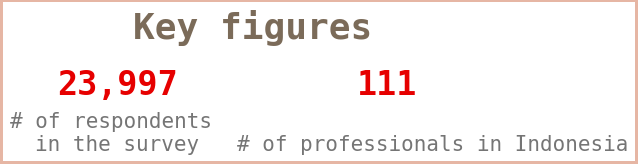

In [ ]:
mpl.rcParams.update(mpl.rcParamsDefault)

fig1 = plt.figure(figsize=(5,2),facecolor='white')

ax1 = fig1.add_subplot(1,1,1)
font = 'monospace'
ax1.text(0.3, 0.8, "Key figures",color='#7b6b59',fontsize=26, fontweight='bold', fontfamily=font, ha='center')


ax1.text(0, 0.4, "{:,d}".format(df.shape[0]), color='#e60000', fontsize=24, fontweight='bold', fontfamily=font, ha='center')
ax1.text(0, 0.001, "# of respondents \nin the survey",color='#757575',fontsize=15, fontweight='light', fontfamily=font,ha='center')

ax1.text(0.6, 0.4, "{}".format(indonesia_df.shape[0]), color='#e60000', fontsize=24, fontweight='bold', fontfamily=font, ha='center')
ax1.text(0.7, 0.001, "# of professionals in Indonesia",color='#757575',fontsize=15, fontweight='light', fontfamily=font,ha='center')

ax1.set_yticklabels('')
ax1.tick_params(axis='y',length=0)
ax1.tick_params(axis='x',length=0)
ax1.set_xticklabels('')

for direction in ['top','right','left','bottom']:
    ax1.spines[direction].set_visible(False)

fig1.subplots_adjust(top=0.9, bottom=0.2, left=0, hspace=1)

fig1.patch.set_linewidth(3)
fig1.patch.set_edgecolor('#E6b6a4')
fig1.patch.set_facecolor('white')
ax1.set_facecolor('white')

plt.show()

In [ ]:
multiple_choice_questions = {}
seen_columns = []

for col in indonesia_df.columns:
    question = col.split("_")[0]
    if question in seen_columns:
        if question not in multiple_choice_questions:
            multiple_choice_questions[question] = 2
        else:
            multiple_choice_questions[question] = multiple_choice_questions[question] + 1
    else:
        seen_columns.append(question)

for col in list(multiple_choice_questions.keys()):
    indonesia_df[f"{col}_number_of_responses"] = indonesia_df.apply(
        lambda x : extract_the_number_of_responses(col,x, df.columns), axis = 1)

In [ ]:
outlier_analysis = []

for col in list(multiple_choice_questions.keys()):
    mean_responses = round(indonesia_df[f"{col}_number_of_responses"].mean())
    outlier_analysis.append([
        col,
        multiple_choice_questions[col],
        mean_responses,
    ])

average_responses = pd.DataFrame(outlier_analysis, columns = ["Question", "Nbr of available Choices", "Average number of selected choices"])
average_responses["Question Title"] = questions_titles[[f"{col}_1" for col in list(multiple_choice_questions.keys())]].loc[0].to_list()
average_responses["Question Title"] = average_responses["Question Title"].apply(lambda x : x.split("(Select")[0].strip())

#Updates the DataFrame in place
indonesia_df.drop([f"{col}_number_of_responses" for col in list(multiple_choice_questions.keys())], axis = 1, inplace=True)

average_responses["Question Title"] = average_responses['Question Title'].str.wrap(80)
average_responses = average_responses[["Question", "Question Title", "Nbr of available Choices", "Average number of selected choices"]]
wrap_df_text(average_responses)

,Question,Question Title,Nbr of available Choices,Average number of selected choices
0,Q28,Select any activities that make up an important part of your role at work:,8,2




*   Top AI Jobs in Indonesia Market



In [ ]:
data_science_rolesIndonesia = indonesia_df.groupby(["Q23"]).agg({"Q2" : "count"}).reset_index().rename(columns={"Q2": "counts"})

data_science_rolesIndonesia["relative_percent"] = data_science_rolesIndonesia.apply(lambda x : (x["counts"] / indonesia_df.shape[0]), axis = 1)
data_science_rolesIndonesia = data_science_rolesIndonesia.sort_values(by=["relative_percent"], ascending=True)
data_science_rolesIndonesia = data_science_rolesIndonesia[~data_science_rolesIndonesia["Q23"].isin(["None", "Other"])]


create_single_bar_plot(
    x_values=data_science_rolesIndonesia["relative_percent"].to_list(),
    y_values=data_science_rolesIndonesia["Q23"].to_list(),
    display_text=np.round((data_science_rolesIndonesia["relative_percent"] *100), decimals = 2),
    top_n=2,
    rest_n=data_science_rolesIndonesia.shape[0]-2,
    hovertext = data_science_rolesIndonesia["counts"].to_list(),
    title="Top AI Jobs in Indonesia",
    subtitle="",
    orientation="h"
)

Industries That Hiring Most AI Technology Specialists in Indonesia

In [ ]:
industry_totals = indonesia_df["Q24"].value_counts().to_dict()
industry_totals

{'Academics/Education': 35,
 'Computers/Technology': 19,
 'Accounting/Finance': 11,
 'Manufacturing/Fabrication': 10,
 'Retail/Sales': 8,
 'Government/Public Service': 5,
 'Marketing/CRM': 5,
 'Medical/Pharmaceutical': 4,
 'Other': 4,
 'Energy/Mining': 3,
 'Shipping/Transportation': 2,
 'Non-profit/Service': 2,
 'Online Service/Internet-based Services': 2,
 'Broadcasting/Communications': 1}

In [ ]:
roles_df = indonesia_df.groupby(["Q24", "Q23"]).agg({"Q2" : "count"}).reset_index().rename(columns={"Q2": "counts"})
roles_df["relative_percent"] = roles_df.apply(lambda x : x["counts"] / industry_totals[x["Q24"]], axis = 1)

create_scatter_plot(
    roles_df["Q23"].apply(lambda x : x.split("(")[0]),
    roles_df["Q24"],
     "Role: %{x}<br>" +
        "Industry: %{y}<br>" +
        "Percentage: %{marker.size:,}" +
        "<extra></extra>",
    roles_df['relative_percent']*100,
    roles_df['relative_percent']*50,
    "What Industries are Hiring the Most AI Technology Specialists?",
    "Questions Data: Industry (Q24) and Job Role (Q23)",
    "Size,Color: Percentage of Respondents - <br>The number of respondents with the relevant job position in the related sector<br>divided by the total number of respondents working in that sector."
)

In [ ]:
dfs_list = []
ml_indonesia_df = indonesia_df[
    (indonesia_df["Q23"].isin(["Machine Learning/ MLops Engineer", "Data Scientist"])) |
    (indonesia_df["Q23"].str.contains("Data Analyst"))
]

for col in [column for column in df.columns if column.startswith("Q28")]:
    dfs_list.append(ml_indonesia_df.groupby([col]).agg({"Q2" : "count"}).reset_index().rename(columns={"Q2": "counts", col: "ML Activities"}))

ml_activities = pd.concat(dfs_list)
ml_activities["relative_percent"] = ml_activities.apply(lambda x : x["counts"] / ml_activities["counts"].sum(), axis = 1)


ml_activities = ml_activities.sort_values(by=["relative_percent"], ascending=False)
ml_activities = ml_activities[
    ~((ml_activities["ML Activities"].str.contains("None")) |
    (ml_activities["ML Activities"].str.contains("Other")))
]


map_ml_activities = {
    "Analyze and understand data to influence product or business decisions": "Analyze and understand data<br>to influence product or business decisions" ,
    "Build prototypes to explore applying machine learning to new areas": "Build prototypes to explore <br>applying machine learning to new areas",
    "Build and/or run the data infrastructure that my business uses for storing, analyzing, and operationalizing data": "Build and/or run the data infrastructure",
    "Experimentation and iteration to improve existing ML models": "Experimentation and iteration<br>to improve existing ML models",
    "Build and/or run a machine learning service that operationally improves my product or workflows": "Build and/or run a machine learning service",
    "Do research that advances the state of the art of machine learning": "Do research that advances the<br>state of the art of machine learning"

}
ml_activities["ML Activities"] = ml_activities["ML Activities"].apply(lambda x : map_ml_activities[x])

fig = go.Figure(go.Funnelarea(
      values = ml_activities["counts"].to_list(), text = ml_activities["ML Activities"].to_list(),
      marker = {"colors": ["#fa4f2d","#fa4f2d","#fa752d", "#fa972d", "#faa125", "#face2d", "#face2d"],
              },
      textfont = {"family": "Times New Roman", "size": 22, "color": "black"}, opacity = 0.65))

large_title_format = "<span style='font-size:30px; font-family:Times New Roman'>A Day in the Life of a Data Scientist / Analyst or ML Engineer</span>"


layout = dict(
    title = large_title_format,
    font = dict(color = '#7b6b59'),
    margin = dict(t=170),
    width = 800,
    height= 700,
    plot_bgcolor = "white"
)

fig.update_layout(layout)
fig.update_traces(showlegend=False)
fig.show()

In [ ]:
jobs_in_scope = [
    "Data Scientist",
    "Data Analyst (Business, Marketing, Financial, Quantitative, etc)",
    "Research Scientist",
    "Machine Learning/ MLops Engineer"
]
activities = [col for col in df.columns if col.startswith("Q28")]
job_roles = indonesia_df["Q23"].str.strip().value_counts().to_dict()
dfs_list = []
for role in jobs_in_scope:
    for col in activities:
        roles_df = indonesia_df[
            indonesia_df["Q23"].str.strip() == role
        ].groupby(["Q23", col]).agg({"Q2" : "count"}).reset_index().rename(columns={"Q2": "counts", col: "ML Activities"})
        dfs_list.append(roles_df)

results = pd.concat(dfs_list)

results["Q23"] = results["Q23"].str.strip()
results["relative_percent"] = results.apply(lambda x : x["counts"] / job_roles[x["Q23"]], axis = 1)
results = results[
    ~((results["ML Activities"].str.contains("None")) |
    (results["ML Activities"].str.contains("Other")))
]


map_ml_activities = {
    "Analyze and understand data to influence product or business decisions": "1. Analyze and understand data<br><sup>to influence product or business decisions</sup>" ,
    "Build prototypes to explore applying machine learning to new areas": "2. Build prototypes to explore <br><sup>applying machine learning to new areas</sup>",
    "Build and/or run the data infrastructure that my business uses for storing, analyzing, and operationalizing data": "3. Build and/or run the data infrastructure</sup>",
    "Experimentation and iteration to improve existing ML models": "4. Experimentation and iteration<br><sup>to improve existing ML models</sup>",
    "Build and/or run a machine learning service that operationally improves my product or workflows": "5. Build and/or run a machine learning service",
    "Do research that advances the state of the art of machine learning": "6. Do research that advances <br><sup>the state of the art of machine learning</sup>"

}
results["ML Activities"] = results["ML Activities"].apply(lambda x : map_ml_activities[x])

results = results.sort_values(by=["ML Activities"], ascending=False)


create_scatter_plot(
    results["Q23"].apply(lambda x : x.split("(")[0]).to_list(),
    results["ML Activities"].apply(lambda x : x.split("(")[0]),
     "Role: %{x}<br>" +
        "ML Activity: %{y}<br>" +
        "Percentage: %{marker.size:,}" +
        "<extra></extra>",
    results['relative_percent']*100,
    results['relative_percent']*100,
    "Tasks among ML and Data Science Roles",
    "Questions Data: ML Activity (Q28) and Job Role (Q23)",
    "Size,Color: Percentage of Respondents - <br>The number of respondents with the relevant job position doing the respective ML activity<br>divided by the total number of respondents with the same job position."
)



*   Distribution of AI Jobs in Indonesia based on gender



In [ ]:
genderIndonesia = indonesia_df.groupby(["Q3"]).agg({"Q2" : "count"}).reset_index().rename(columns={"Q2": "counts"})
genderIndonesia["relative_percent"] = genderIndonesia.apply(lambda x : (x["counts"] / indonesia_df.shape[0]), axis = 1)
genderIndonesia = genderIndonesia.sort_values(by=["relative_percent"], ascending=True)
genderIndonesia = genderIndonesia[~genderIndonesia["Q3"].isin(["None", "Other"])]


import plotly.express as px

fig = px.pie(genderIndonesia,
             values="relative_percent",
             names="Q3",
             title="Gender Distribution",
             hover_data=["counts"],
             labels={"relative_percent": "Percentage", "Q3": "Gender"},
             color_discrete_sequence=["#fa4f2d","#fa752d", "#fa972d"]  # Anda dapat mengganti kode warna sesuai preferensi Anda
            )

fig.update_traces(textinfo="percent+label", pull=[0.1, 0])

fig.show()





*   Educational Qualifications



In [ ]:
educationIndonesia_df = indonesia_df.groupby(["Q8"]).agg({"Q2" : "count"}).reset_index().rename(columns={"Q8": "education_level", "Q2": "counts"})

educationIndonesia_df["relative_percent"] = educationIndonesia_df.apply(lambda x : (x["counts"] / indonesia_df.shape[0]), axis = 1)
educationIndonesia_df = educationIndonesia_df.sort_values(by=["relative_percent"], ascending=True)

create_single_bar_plot(
    x_values=educationIndonesia_df["relative_percent"].to_list(),
    y_values=educationIndonesia_df["education_level"].to_list(),
    display_text=np.round((educationIndonesia_df["relative_percent"] * 100), decimals=2),
    top_n=2,
    rest_n=educationIndonesia_df.shape[0]-2,
    hovertext=educationIndonesia_df["counts"].to_list(),
    title="Educational Qualifications",
    subtitle="",
    orientation="h"
)

# K-Means

In [ ]:
!pip install researchpy
import numpy as np
import pandas as pd
import researchpy as rp
import seaborn as sns
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [ ]:
datakm = indonesia_df.loc[:,['Q2','Q3','Q8']]

In [ ]:
datakm

,Q2,Q3,Q8
42,50-54,Man,Doctoral degree
283,30-34,Man,Bachelor’s degree
379,22-24,Man,Bachelor’s degree
413,30-34,Man,I prefer not to answer
664,25-29,Man,Bachelor’s degree
...,...,...,...
22552,22-24,Woman,Bachelor’s degree
22890,30-34,Man,I prefer not to answer
23014,25-29,Woman,Master’s degree
23445,55-59,Man,Doctoral degree


In [ ]:
datakm.drop_duplicates(keep=False)
datakm.drop_duplicates(keep=False, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder #changing to numerical by label encoder
number = LabelEncoder()
datakm["Q2"] = number.fit_transform(datakm["Q2"].astype('str'))
datakm["Q3"] = number.fit_transform(datakm["Q3"].astype('str'))
datakm["Q8"] = number.fit_transform(datakm["Q8"].astype('str'))

In [ ]:
datakm.Q2 = pd.to_numeric(datakm.Q2)  #change to numeric type data
datakm.Q3 = pd.to_numeric(datakm.Q3)
datakm.Q8 = pd.to_numeric(datakm.Q8)

In [ ]:
indonesiaDf_onehot = datakm.copy()
indonesiaDf_onehot = pd.get_dummies(indonesiaDf_onehot, columns = ['Q2','Q3','Q8'], prefix = ['Q2','Q3','Q8'] )

In [ ]:
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
Nchs = SS.fit_transform(indonesiaDf_onehot)

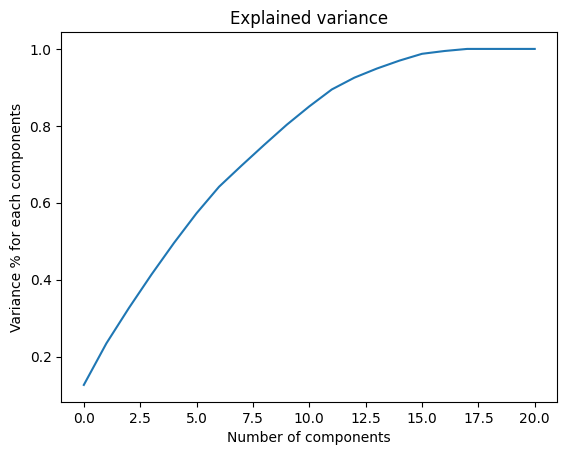

In [ ]:
from sklearn.decomposition import PCA
#fitting the pca algorithm with our data
pca=PCA().fit(Nchs)
#plotting the cumulative summation of the explained variance
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Variance % for each components')
plt.title('Explained variance')
plt.show()

In [ ]:
pca=PCA(n_components=16)
pca.fit(Nchs)
x_pca=pca.transform(Nchs)

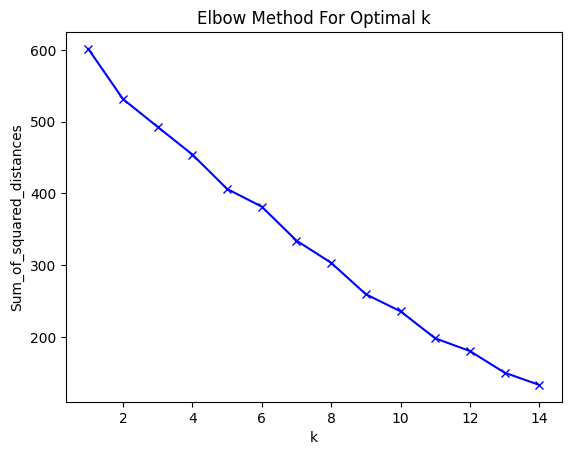

In [ ]:
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

Sum_of_squared_distances = []
K = range(1, 15)

for k in K:
    kmi = KMeans(n_clusters=k)
    kmi = kmi.fit(x_pca)
    Sum_of_squared_distances.append(kmi.inertia_)

# Visualizing the plot
plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='auto')
y_kmeans=kmeans.fit_predict(x_pca)

In [ ]:
#Menampilkan hasil cluster
print(y_kmeans)

[0 0 1 0 0 1 1 0 0 1 1 0 1 1 1 0 0 0 0 0 0 1 0 0 1 0 1 1 1]


In [ ]:
# Menambahkan kolom "kluster" dalam data_kMeans
datakm["kluster"] = y_kmeans
datakm

,Q2,Q3,Q8,kluster
1773,5,1,2,0
2301,8,2,2,0
2319,1,0,6,1
2732,2,2,4,0
2944,6,2,5,0
3763,9,0,5,1
6014,7,0,0,1
6102,3,2,0,0
6427,5,0,0,0
7632,3,0,6,1


In [ ]:
df2 = pd.DataFrame(datakm)
# Set opsi untuk menampilkan semua baris dan kolom
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Tampilkan DataFrame
df2

,Q2,Q3,Q8,kluster
1773,5,1,2,0
2301,8,2,2,0
2319,1,0,6,1
2732,2,2,4,0
2944,6,2,5,0
3763,9,0,5,1
6014,7,0,0,1
6102,3,2,0,0
6427,5,0,0,0
7632,3,0,6,1


In [ ]:
cluster1 = df2[df2['kluster'] == 0]
cluster1.count()

Q2         16
Q3         16
Q8         16
kluster    16
dtype: int64

In [ ]:
cluster2 = df2[df2['kluster'] == 1]
cluster2.count()

Q2         13
Q3         13
Q8         13
kluster    13
dtype: int64

Dari data k-means dengan total **11.961**. Sebanyak **15** tergolong ke dalam **cluster 1** dan **14** tergolong ke dalam **cluster 2**.

In [ ]:
cluster1.head(15)

,Q2,Q3,Q8,kluster
1773,5,1,2,0
2301,8,2,2,0
2732,2,2,4,0
2944,6,2,5,0
6102,3,2,0,0
6427,5,0,0,0
8060,5,2,1,0
12040,2,2,0,0
13936,2,2,6,0
15031,8,2,3,0


In [ ]:
cluster2.head(14)

,Q2,Q3,Q8,kluster
2319,1,0,6,1
3763,9,0,5,1
6014,7,0,0,1
7632,3,0,6,1
7674,4,0,2,1
10306,2,0,6,1
10939,7,0,3,1
11075,4,0,3,1
16345,1,0,4,1
17930,6,0,4,1


**Keterangan**

 Baris pertama menggambarkan titik-titik dari klaster 0 (Cluster1) dengan warna merah, sedangkan baris kedua menggambarkan titik-titik dari klaster 1 (Cluster2) dengan warna biru pada scatter plot.

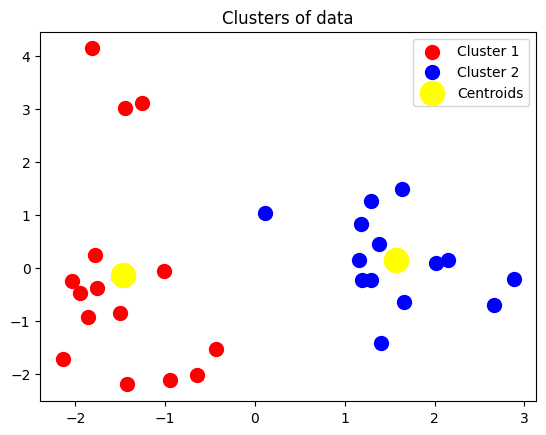

In [ ]:
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans

# Assuming x_pca is your data
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=1000, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='auto')
y_kmeans = kmeans.fit_predict(x_pca)

# Plotting through K-Means
plt.scatter(x_pca[y_kmeans==0, 0], x_pca[y_kmeans==0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(x_pca[y_kmeans==1, 0], x_pca[y_kmeans==1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids')
plt.title('Clusters of data')
plt.legend()
plt.show()